In [1]:
# !pip install tonic


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import sys
sys.path.insert(1, os.getcwd()+'/..')

import numpy as np
import sklearn.metrics as metrics
import torch
import pickle
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from eb_dataset import EB_DS, load_dataset

import warnings

import tonic
import numpy as np

## Loading datasets

In [3]:
# Suppress specific warning
warnings.filterwarnings("ignore", category=UserWarning, module='torch.nn.parallel.scatter_gather')

#load datasets
num_points = 1000
ds = {}
labels = {}
ds['NMN'], labels['NMN'] , __ = load_dataset(tonic_name='NMNIST', tonic_train_split=True, tonic_path='/shareds/',
                                                     n_samples=num_points, do_shuffle=False)
ds['D1'], labels['D1'], _ = load_dataset(base_path='/shareds/eb_datasets/20240623/train/', n_samples=num_points, do_shuffle=False)
ds['D2'], labels['D2'], _ = load_dataset(base_path='/shareds/eb_datasets/20240707/train/', n_samples=num_points, do_shuffle=False)
ds_frames, labels_frames, _ = load_dataset(base_path='/shareds/eb_datasets/20240628/train/', frame_based=True)

loading /shareds/eb_datasets/20240623/train/events.pkl...
/shareds/eb_datasets/20240623/train/labels.pkl
loading /shareds/eb_datasets/20240707/train/events.pkl...
/shareds/eb_datasets/20240707/train/labels.pkl
loading dataset from /shareds/eb_datasets/20240628/train/...
['/shareds/eb_datasets/20240628/train/frames.pkl']
1  ds files found.
loading /shareds/eb_datasets/20240628/train/frames.pkl...
/shareds/eb_datasets/20240628/train/labels.pkl


In [4]:
print(np.unique(labels['D1']))

[0 1 2 3 4 5 6 7 8 9]


## Plotting MNIST D1 frames examples

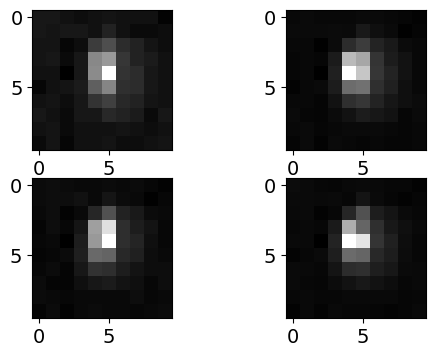

In [5]:
plt.rcParams.update({'font.size': 14})

samples_i=[1,2,3,4]
fig, axs = plt.subplots(2,2, figsize=(6,4))

for plti, samplei in enumerate(samples_i):
    axs[plti//2,plti%2].imshow(ds_frames[samplei][-1][1], cmap='gray')
    
# plt.tight_layout()

## Ploting event-based 3d raster plots

In [6]:
# %matplotlib notebook
#%matplotlib inline
# import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
def filter_by_interval_and_polarity(d,tmin,tmax,p):
    return np.logical_and(np.logical_and(d[:,0]>=tmin, d[:,0]<=tmax), np.abs(d[:,-1]-p)<1e-6)

In [8]:
tparams = {'NMN': [50,60,80],
          'D1': [100.,140, 140],
          'D2': [100.,140, 140],
          }
dd = {'NMN': 23,
          'D1': 8,
          'D2': 8,
          }

180 166 6


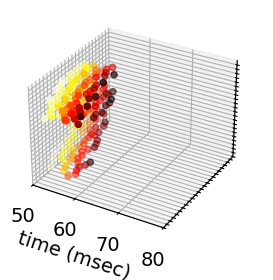

In [54]:
plt.rcParams.update({'font.size': 14})

eps = 1e-9
for this_ds in ['NMN']: #ds:

    # f= plt.figure(figsize=(12,4))
     # f= plt.figure(figsize=(50,12.5))

     for ii, uu in enumerate([41002]):
     # for ii, uu in enumerate(range(41002,41100)): #, 10099]):
        tmin,tmax,tmaxshow = tparams[this_ds]
#         cm = plt.get_cmap("gray")

        f= plt.figure(figsize=(3,4))
        # ax= f.add_subplot(1,2,ii+1,projection='3d')
        # ax= f.add_subplot(20,5,1+ii,projection='3d')
        ax= f.add_subplot(1,1,1,projection='3d')
        d = ds[this_ds][uu]
        iip = filter_by_interval_and_polarity(d,tmin,tmax,0)
        iin = filter_by_interval_and_polarity(d,tmin,tmax,1)

        print(np.sum(iip), np.sum(iin), labels[this_ds][uu])
        # ax.set_title(f'{uu}')
                
        ax.set_xlim([tmin,tmaxshow])
        ax.set_xlabel('time (msec)')

        ax.axes.set_ylim3d(bottom=0.-eps, top=dd[this_ds]+eps) 
        ax.axes.set_zlim3d(bottom=0.-eps, top=dd[this_ds]+eps) 
            
        ax.set_yticks(np.arange(dd[this_ds]))
        ax.set_zticks(np.arange(dd[this_ds]))
        ax.set_yticklabels(['' for _ in ax.get_yticklabels()])
        ax.set_zticklabels(['' for _ in ax.get_zticklabels()])
#         ax.set_xticks([])
        ii = iip

        ax.scatter(d[ii,0], 2+np.max(d[ii,1]) - d[ii,1], 2+d[ii,2] - np.min(d[ii,2]),c = (-d[ii,0] + tmax+1e-9)**0.8, cmap='hot')
        f.savefig('fig1panelD.svg',format='svg')

#         plt.tight_layout()
#         print(ax.xy_viewLim)

In [52]:
np.savetxt(
    "fig1panelD.csv",
    d[ii],
    delimiter=",",
    header="t,x,y,p",
    comments=""
)